# The Fair Die

In [17]:
import numpy as np
import plotly.express as px

# Observed data from 120 die rolls
observed_counts = np.array([5, 28, 25, 20, 22, 20])  # Example counts
N = observed_counts.sum()
N


np.int64(120)

In [19]:
# Compute observed TVD against uniform distribution
observed_props = observed_counts / N
observed_props


array([0.04166667, 0.23333333, 0.20833333, 0.16666667, 0.18333333,
       0.16666667])

In [20]:
uniform = np.full(6, 1/6)
uniform

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [22]:
observed_tvd = np.sum(np.abs(observed_props - uniform)) / 2
observed_tvd

np.float64(0.125)

In [23]:

# Simulate the null distribution (fair die)
n_reps = 100_000
simulated_counts = np.random.multinomial(N, uniform, size=n_reps)
simulated_props = simulated_counts / N
simulated_props



array([[0.125     , 0.18333333, 0.175     , 0.2       , 0.15833333,
        0.15833333],
       [0.175     , 0.15      , 0.125     , 0.20833333, 0.13333333,
        0.20833333],
       [0.15833333, 0.09166667, 0.21666667, 0.18333333, 0.18333333,
        0.16666667],
       ...,
       [0.20833333, 0.15833333, 0.16666667, 0.125     , 0.15833333,
        0.18333333],
       [0.13333333, 0.21666667, 0.175     , 0.18333333, 0.10833333,
        0.18333333],
       [0.20833333, 0.21666667, 0.14166667, 0.14166667, 0.11666667,
        0.175     ]])

In [26]:
sim_tvd = np.sum(np.abs(simulated_props - uniform), axis=1) / 2
sim_tvd

array([0.05833333, 0.09166667, 0.08333333, ..., 0.05833333, 0.09166667,
       0.1       ])

In [27]:
# Compute p-value
p_val = (sim_tvd >= observed_tvd).mean()
print(f"Observed TVD: {observed_tvd:.4f}")
print(f"P-value: {p_val:.4f}")

Observed TVD: 0.1250
P-value: 0.0810


In [15]:
%pip install tk

Note: you may need to restart the kernel to use updated packages.


# Creativity and Motivation

In [28]:

import numpy as np
import pandas as pd
from tkinter import Tk, filedialog


In [29]:

# --- Step 1: Open file picker dialog ---
Tk().withdraw()  # Hide the root window
file_path = filedialog.askopenfilename(
    title="Select your Creativity.csv file",
    filetypes=[("CSV files", "*.csv"), ("All files", "*.*")]
)

print("You selected:", file_path)


You selected: /Users/bsadler/dsc80-2025-su/resources/sandbox/Creativity.csv


In [30]:
# --- Step 2: Read the data ---
creativity_df = pd.read_csv(file_path)

# Quick peek at the data (optional)
print("\nFirst few rows of the dataset:")
print(creativity_df.head(), "\n")




First few rows of the dataset:
   Score Treatment_S  Treatment
0    5.0   Extrinsic          1
1    5.4   Extrinsic          1
2    6.1   Extrinsic          1
3   10.9   Extrinsic          1
4   11.8   Extrinsic          1 



In [31]:

# copy data
df = creativity_df.copy()

# Observed difference (Intrinsic - Extrinsic)
group_means = df.groupby("Treatment_S")["Score"].mean()
observed_diff = group_means["Intrinsic"] - group_means["Extrinsic"]

observed_diff

np.float64(4.1442028985507235)

In [65]:
# Permutation test
n_reps = 1000
diffs = []

#rng = np.random.default_rng(2)  # reproducibility
for _ in range(n_reps):
    shuffled = df.assign(
        Shuffled_Treatment = rng.permutation(df["Treatment_S"].to_numpy())
    )
    means = shuffled.groupby("Shuffled_Treatment")["Score"].mean()
    diffs.append(means["Intrinsic"] - means["Extrinsic"])

# Convert to array
diffs = np.array(diffs)

diffs

array([ 4.02173913e-02,  1.46739130e-02,  2.10507246e-01, -2.89728261e+00,
        1.11304348e+00,  3.17028986e-02, -2.08840580e+00, -3.45072464e+00,
       -9.98550725e-01,  4.02173913e-02,  6.27717391e-01,  7.38405797e-01,
        1.50471014e+00, -2.07989130e+00, -3.52735507e+00,  1.08333333e-01,
        1.50905797e-01,  8.23550725e-01,  1.04492754e+00, -1.50090580e+00,
       -1.72228261e+00, -2.32246377e-01, -1.93840580e-02, -2.18206522e+00,
        1.16413043e+00, -2.25018116e+00,  7.63949275e-01, -1.09221014e+00,
        3.68442029e+00,  6.61775362e-01, -3.68061594e+00, -3.87644928e+00,
        1.63242754e+00,  2.23695652e+00,  1.67934783e-01,  1.08333333e-01,
       -2.10543478e+00,  8.66123188e-01,  4.28043478e+00, -1.15181159e+00,
        5.42572464e-01, -1.20289855e+00, -3.08876812e-01,  1.92192029e+00,
       -6.57971014e-01,  1.15561594e+00, -1.13043478e-01, -1.47536232e+00,
        1.58134058e+00,  1.84963768e-01, -2.57789855e-01, -5.64311594e-01,
       -3.05054348e+00,  

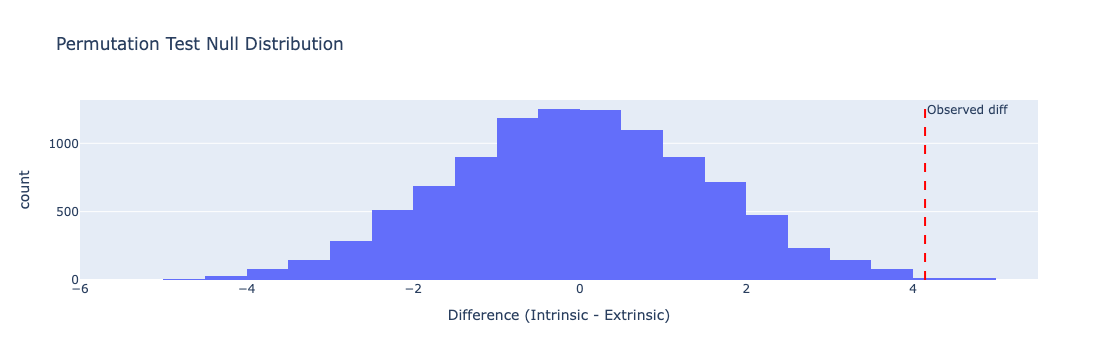

In [33]:
import plotly.express as px

fig = px.histogram(
    x=diffs,
    nbins=50,
    title="Permutation Test Null Distribution",
    labels={"x": "Difference (Intrinsic - Extrinsic)", "y": "Count"}
)

# Add observed difference as vertical line
fig.add_vline(x=observed_diff, line_color="red", line_dash="dash", 
              annotation_text="Observed diff", annotation_position="top right")

fig.show()

In [66]:
# Two-sided p-value
p_val = np.mean(np.abs(diffs) >= abs(observed_diff))

print("Observed difference:", observed_diff)
print("P-value:", p_val)

Observed difference: 4.1442028985507235
P-value: 0.003
